# 03. Preprocessing para Deep Learning — MIMIC-IV-ED

Este notebook prepara el dataset completo para modelos de Deep Learning sobre la tarea de **predicción de readmisión a urgencias en 30 días**.

### Estructura del notebook
1. Setup y carga de datos
2. Creación de la variable objetivo (`readmit_30d`)
3. Análisis de NaNs y missingness
4. Distribuciones: histogramas y boxplots
5. Detección y tratamiento de outliers
6. Feature Engineering avanzado
7. Encoding de variables categóricas
8. Normalización / Escalado
9. Dataset final listo para DL

---
## 1. Setup y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

# ── Ajusta estos paths a tu entorno ──────────────────────────────────────────
DATA_PATH = "mimic-iv-ed-2.2/ed"
import os

df_edstays  = pd.read_csv(os.path.join(DATA_PATH, 'edstays.csv.gz'))
df_triage   = pd.read_csv(os.path.join(DATA_PATH, 'triage.csv.gz'))
df_vitals   = pd.read_csv(os.path.join(DATA_PATH, 'vitalsign.csv.gz'))
df_diag     = pd.read_csv(os.path.join(DATA_PATH, 'diagnosis.csv.gz'))
df_pyxis    = pd.read_csv(os.path.join(DATA_PATH, 'pyxis.csv.gz'))

print('Tablas cargadas:')
for name, df in [('edstays', df_edstays), ('triage', df_triage),
                 ('vitalsign', df_vitals), ('diagnosis', df_diag), ('pyxis', df_pyxis)]:
    print(f'  {name:12s}: {df.shape[0]:>9,} filas × {df.shape[1]} columnas')

Tablas cargadas:
  edstays     :   425,087 filas × 9 columnas
  triage      :   425,087 filas × 11 columnas
  vitalsign   : 1,564,610 filas × 11 columnas
  diagnosis   :   899,050 filas × 6 columnas
  pyxis       : 1,586,053 filas × 7 columnas


---
## 2. Variable objetivo: `readmit_30d`

Para cada visita, calculamos si el mismo paciente volvió a urgencias dentro de los **30 días** siguientes al alta.

Total visitas : 425,087
Readmitidos   : 66,556  (15.7%)
No readmitidos: 358,531  (84.3%)


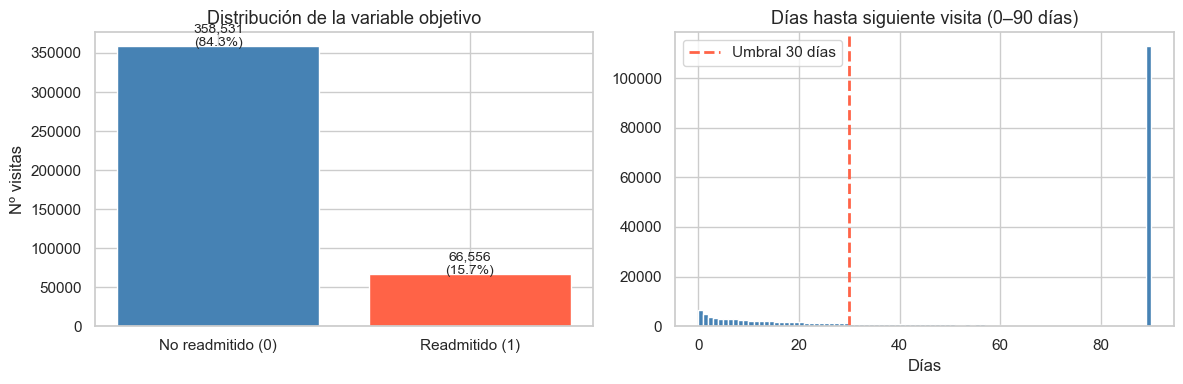


⚠️  Desbalance de clases: ratio 5.4:1 (negativo:positivo)
→ Se deberá usar class_weight o oversampling en el modelo DL.


In [2]:
df_edstays['intime']  = pd.to_datetime(df_edstays['intime'])
df_edstays['outtime'] = pd.to_datetime(df_edstays['outtime'])

df_ed = df_edstays.sort_values(['subject_id', 'intime']).copy()

# Próxima visita del mismo paciente
df_ed['next_intime'] = df_ed.groupby('subject_id')['intime'].shift(-1)
df_ed['days_to_next'] = (df_ed['next_intime'] - df_ed['outtime']).dt.total_seconds() / 86400

# Target binario: 1 si vuelve en <=30 días
df_ed['readmit_30d'] = (df_ed['days_to_next'] <= 30).astype(float)
# La última visita de cada paciente no puede ser positiva (no hay siguiente visita)
last_visit = df_ed.groupby('subject_id')['intime'].transform('max')
df_ed.loc[df_ed['intime'] == last_visit, 'readmit_30d'] = 0

n_total = len(df_ed)
n_pos   = df_ed['readmit_30d'].sum()
print(f'Total visitas : {n_total:,}')
print(f'Readmitidos   : {int(n_pos):,}  ({100*n_pos/n_total:.1f}%)')
print(f'No readmitidos: {int(n_total - n_pos):,}  ({100*(1 - n_pos/n_total):.1f}%)')

# Visualizar desbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df_ed['readmit_30d'].value_counts()
axes[0].bar(['No readmitido (0)', 'Readmitido (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_ylabel('Nº visitas')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({100*v/n_total:.1f}%)', ha='center', fontsize=10)

# Distribución de días hasta la próxima visita (zoom 0-90 días)
days = df_ed['days_to_next'].dropna().clip(0, 90)
axes[1].hist(days, bins=90, color='steelblue', edgecolor='white')
axes[1].axvline(30, color='tomato', linestyle='--', linewidth=2, label='Umbral 30 días')
axes[1].set_title('Días hasta siguiente visita (0–90 días)')
axes[1].set_xlabel('Días')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'\n⚠️  Desbalance de clases: ratio {(n_total - n_pos)/n_pos:.1f}:1 (negativo:positivo)')
print('→ Se deberá usar class_weight o oversampling en el modelo DL.')

---
## 3. Análisis de NaNs y Missingness

Antes de imputar o eliminar, conviene entender el **patrón** de los valores ausentes: ¿son aleatorios (MCAR), dependientes de otras variables (MAR), o sistemáticos (MNAR)?

In [3]:
# ── 3.1 Resumen global de NaNs por tabla ─────────────────────────────────────
print('='*60)
print('% NaN por columna y tabla')
print('='*60)

for name, df in [('edstays', df_ed), ('triage', df_triage), ('vitalsign', df_vitals)]:
    nan_pct = df.isnull().mean().sort_values(ascending=False)
    nan_pct = nan_pct[nan_pct > 0]
    if len(nan_pct) > 0:
        print(f'\n--- {name} ---')
        for col, pct in nan_pct.items():
            bar = '█' * int(pct * 30)
            print(f'  {col:20s}: {100*pct:5.1f}%  {bar}')
    else:
        print(f'\n--- {name}: sin NaNs ---')

% NaN por columna y tabla

--- edstays ---
  hadm_id             :  52.2%  ███████████████
  next_intime         :  48.3%  ██████████████
  days_to_next        :  48.3%  ██████████████

--- triage ---
  temperature         :   5.5%  █
  o2sat               :   4.8%  █
  resprate            :   4.8%  █
  dbp                 :   4.5%  █
  sbp                 :   4.3%  █
  heartrate           :   4.0%  █
  pain                :   3.0%  
  acuity              :   1.6%  
  chiefcomplaint      :   0.0%  

--- vitalsign ---
  rhythm              :  96.2%  ████████████████████████████
  temperature         :  36.1%  ██████████
  pain                :  28.3%  ████████
  o2sat               :   8.7%  ██
  resprate            :   5.7%  █
  sbp                 :   5.2%  █
  dbp                 :   5.2%  █
  heartrate           :   4.5%  █


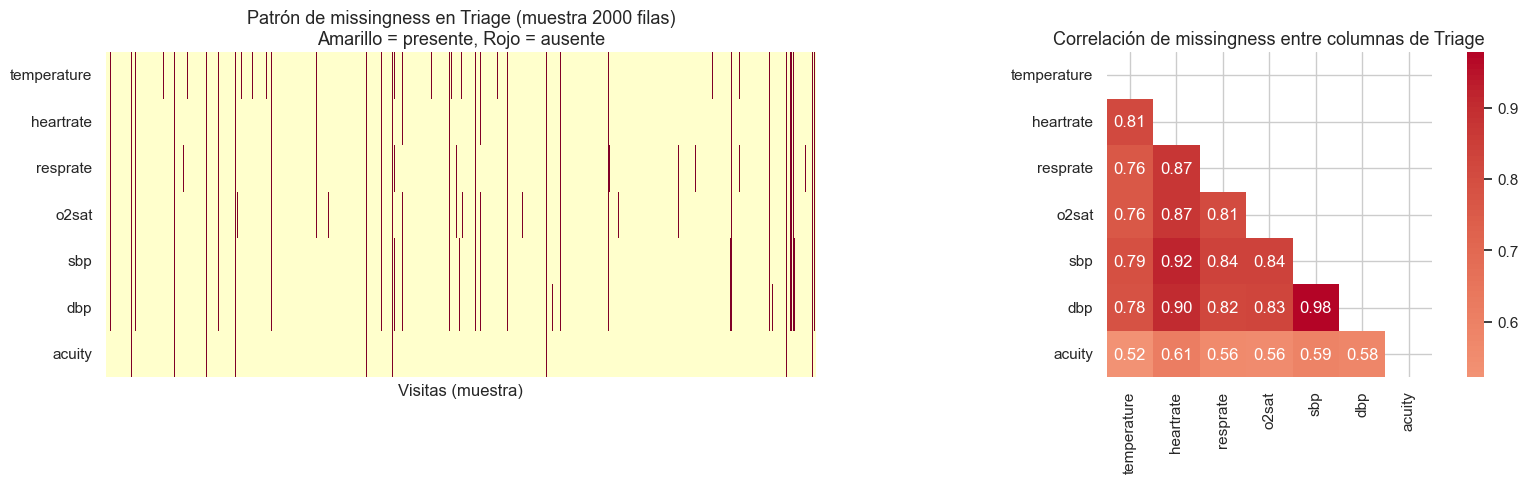

Interpretación:
  - Correlaciones altas → las variables faltan JUNTAS (probablemente el paciente no fue evaluado)
  - Correlaciones bajas → cada variable falta por razones independientes


In [4]:
# ── 3.2 Heatmap de missingness (triage) ──────────────────────────────────────
triage_num_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'acuity']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap de NaN en muestra de triage
sample_missing = df_triage[triage_num_cols].isnull().astype(int).sample(2000, random_state=42)
sns.heatmap(sample_missing.T, cmap='YlOrRd', cbar=False, ax=axes[0],
            yticklabels=triage_num_cols, xticklabels=False)
axes[0].set_title('Patrón de missingness en Triage (muestra 2000 filas)\nAmarillo = presente, Rojo = ausente')
axes[0].set_xlabel('Visitas (muestra)')

# Co-ocurrencia de NaNs: ¿qué columnas faltan juntas?
miss_corr = df_triage[triage_num_cols].isnull().corr()
mask = np.triu(np.ones_like(miss_corr, dtype=bool))
sns.heatmap(miss_corr, annot=True, fmt='.2f', mask=mask, cmap='coolwarm',
            center=0, ax=axes[1], square=True)
axes[1].set_title('Correlación de missingness entre columnas de Triage')
plt.tight_layout()
plt.show()

print('Interpretación:')
print('  - Correlaciones altas → las variables faltan JUNTAS (probablemente el paciente no fue evaluado)')
print('  - Correlaciones bajas → cada variable falta por razones independientes')

In [5]:
# ── 3.3 ¿El missingness está relacionado con el target? ──────────────────────
# Unir triage con target
triage_with_target = df_triage.merge(df_ed[['stay_id', 'readmit_30d']], on='stay_id', how='left')

print('Tasa de readmisión según si temperature en triage está disponible:')
print(triage_with_target.groupby(triage_with_target['temperature'].isnull())['readmit_30d']
      .agg(['mean', 'count']).rename(index={True: 'Temp ausente', False: 'Temp presente'}))

print()
print('Tasa de readmisión según si heartrate en triage está disponible:')
print(triage_with_target.groupby(triage_with_target['heartrate'].isnull())['readmit_30d']
      .agg(['mean', 'count']).rename(index={True: 'HR ausente', False: 'HR presente'}))

print()
print('→ Si las tasas difieren, el missingness es informativo (MAR/MNAR).')
print('→ En ese caso, añadiremos features binarias de indicador de missingness.')

Tasa de readmisión según si temperature en triage está disponible:
                   mean   count
temperature                    
Temp presente  0.158413  401672
Temp ausente   0.124963   23415

Tasa de readmisión según si heartrate en triage está disponible:
                 mean   count
heartrate                    
HR presente  0.158334  407997
HR ausente   0.114453   17090

→ Si las tasas difieren, el missingness es informativo (MAR/MNAR).
→ En ese caso, añadiremos features binarias de indicador de missingness.


In [6]:
# ── 3.4 Vitalsign: rhythm y pain tienen >96% y 28% NaN respectivamente ───────
print('Vitalsign — columnas con muchos NaN:')
print(f'  rhythm: {df_vitals["rhythm"].isnull().mean():.1%} NaN  → se descartará para el modelo')
print(f'  pain  : {df_vitals["pain"].isnull().mean():.1%} NaN  → se procesará como categórica')
print(f'  temp  : {df_vitals["temperature"].isnull().mean():.1%} NaN  → se imputará con mediana por visita')
print()
print('hadm_id en edstays:', f'{df_ed["hadm_id"].isnull().mean():.1%} NaN')
print('→ hadm_id indica si el paciente fue ingresado en hospital. Su ausencia es informativa.')

Vitalsign — columnas con muchos NaN:
  rhythm: 96.2% NaN  → se descartará para el modelo
  pain  : 28.3% NaN  → se procesará como categórica
  temp  : 36.1% NaN  → se imputará con mediana por visita

hadm_id en edstays: 52.2% NaN
→ hadm_id indica si el paciente fue ingresado en hospital. Su ausencia es informativa.


---
## 4. Distribuciones: Histogramas y Boxplots

Visualizamos la distribución real de cada variable numérica, con especial atención a la asimetría y a los valores extremos — especialmente críticos para redes neuronales.

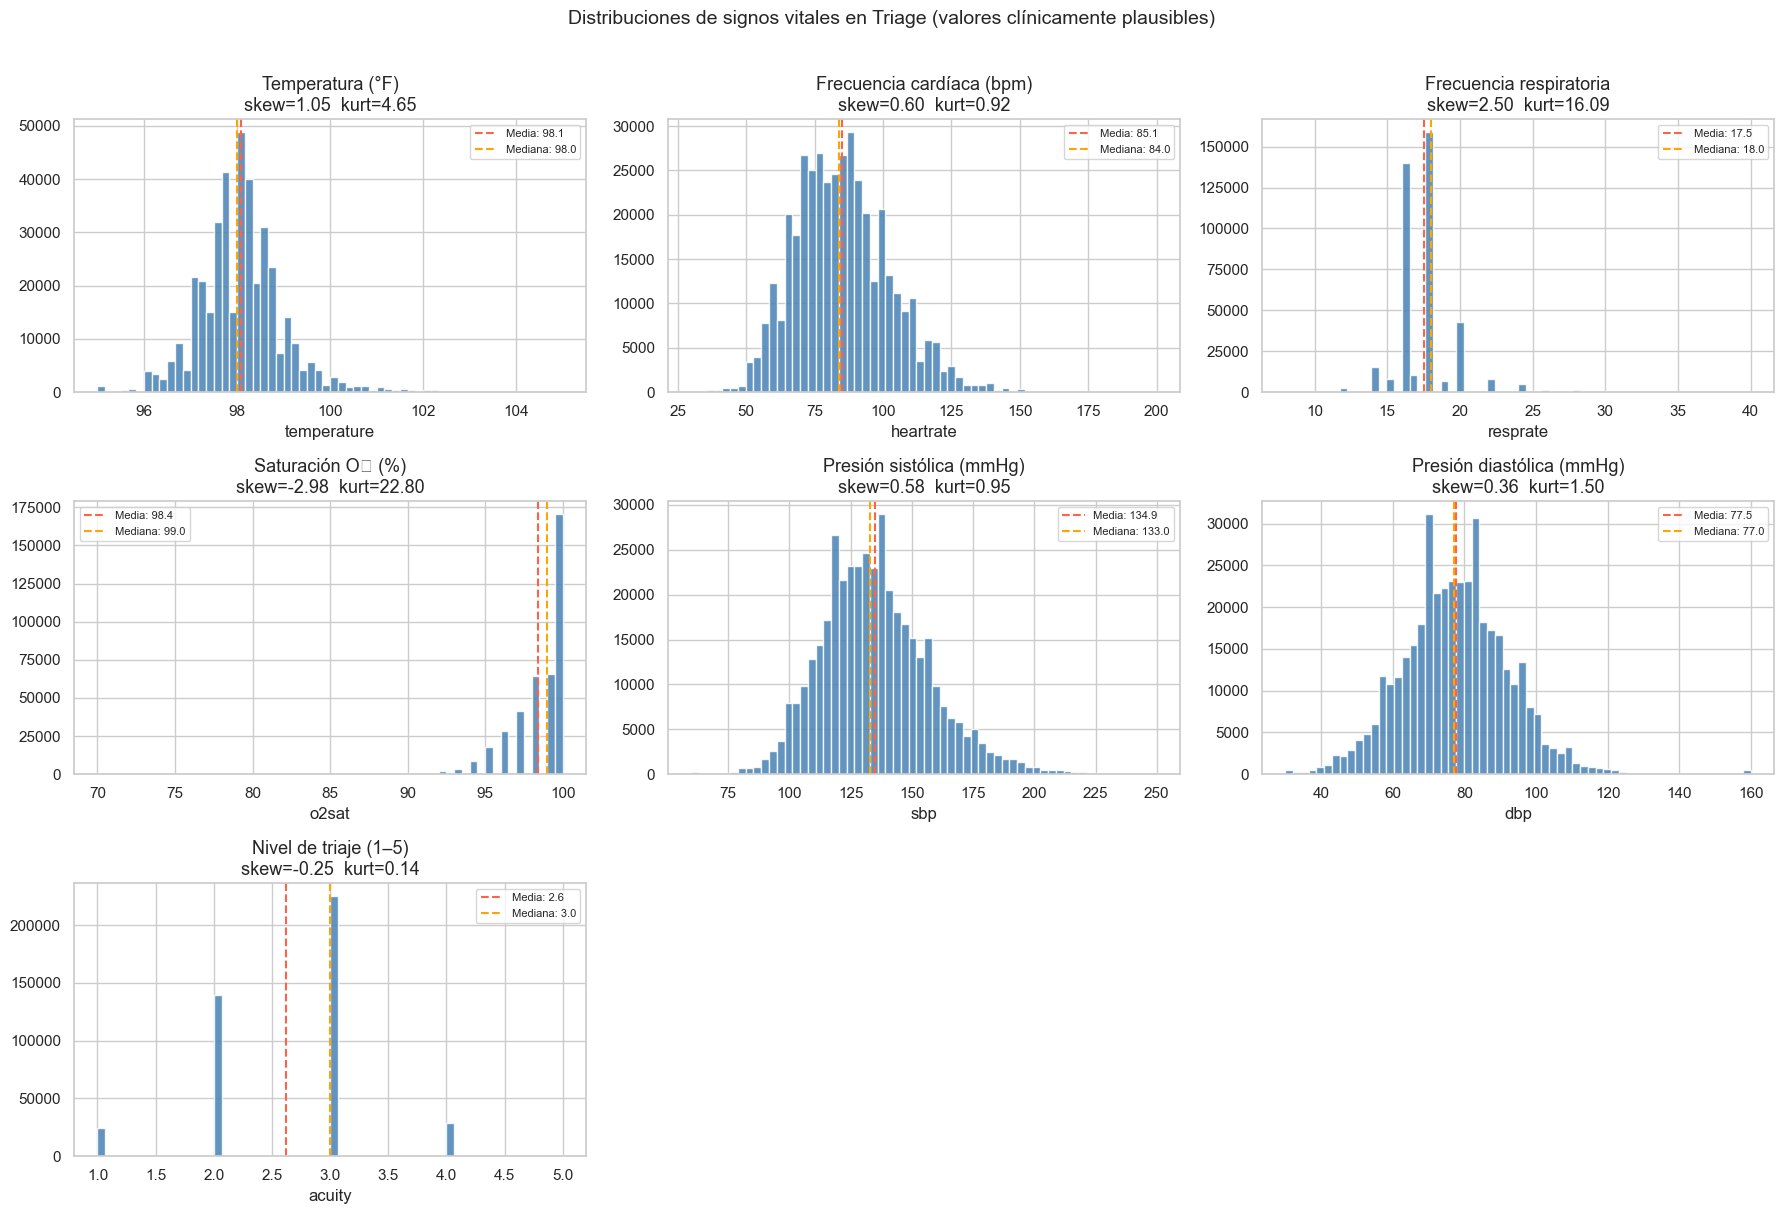

In [7]:
# ── 4.1 Signos vitales en Triage ─────────────────────────────────────────────
vital_meta = {
    'temperature': ('Temperatura (°F)', 95,  105),
    'heartrate'  : ('Frecuencia cardíaca (bpm)', 30, 200),
    'resprate'   : ('Frecuencia respiratoria', 8, 40),
    'o2sat'      : ('Saturación O₂ (%)', 70, 100),
    'sbp'        : ('Presión sistólica (mmHg)', 60, 250),
    'dbp'        : ('Presión diastólica (mmHg)', 30, 160),
    'acuity'     : ('Nivel de triaje (1–5)', 1, 5),
}

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (col, (label, vmin, vmax)) in enumerate(vital_meta.items()):
    data = df_triage[col].dropna().clip(vmin, vmax)
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{label}\nskew={data.skew():.2f}  kurt={data.kurtosis():.2f}')
    axes[i].set_xlabel(col)
    axes[i].axvline(data.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {data.median():.1f}')
    axes[i].legend(fontsize=8)

axes[-2].axis('off')
axes[-1].axis('off')
plt.suptitle('Distribuciones de signos vitales en Triage (valores clínicamente plausibles)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

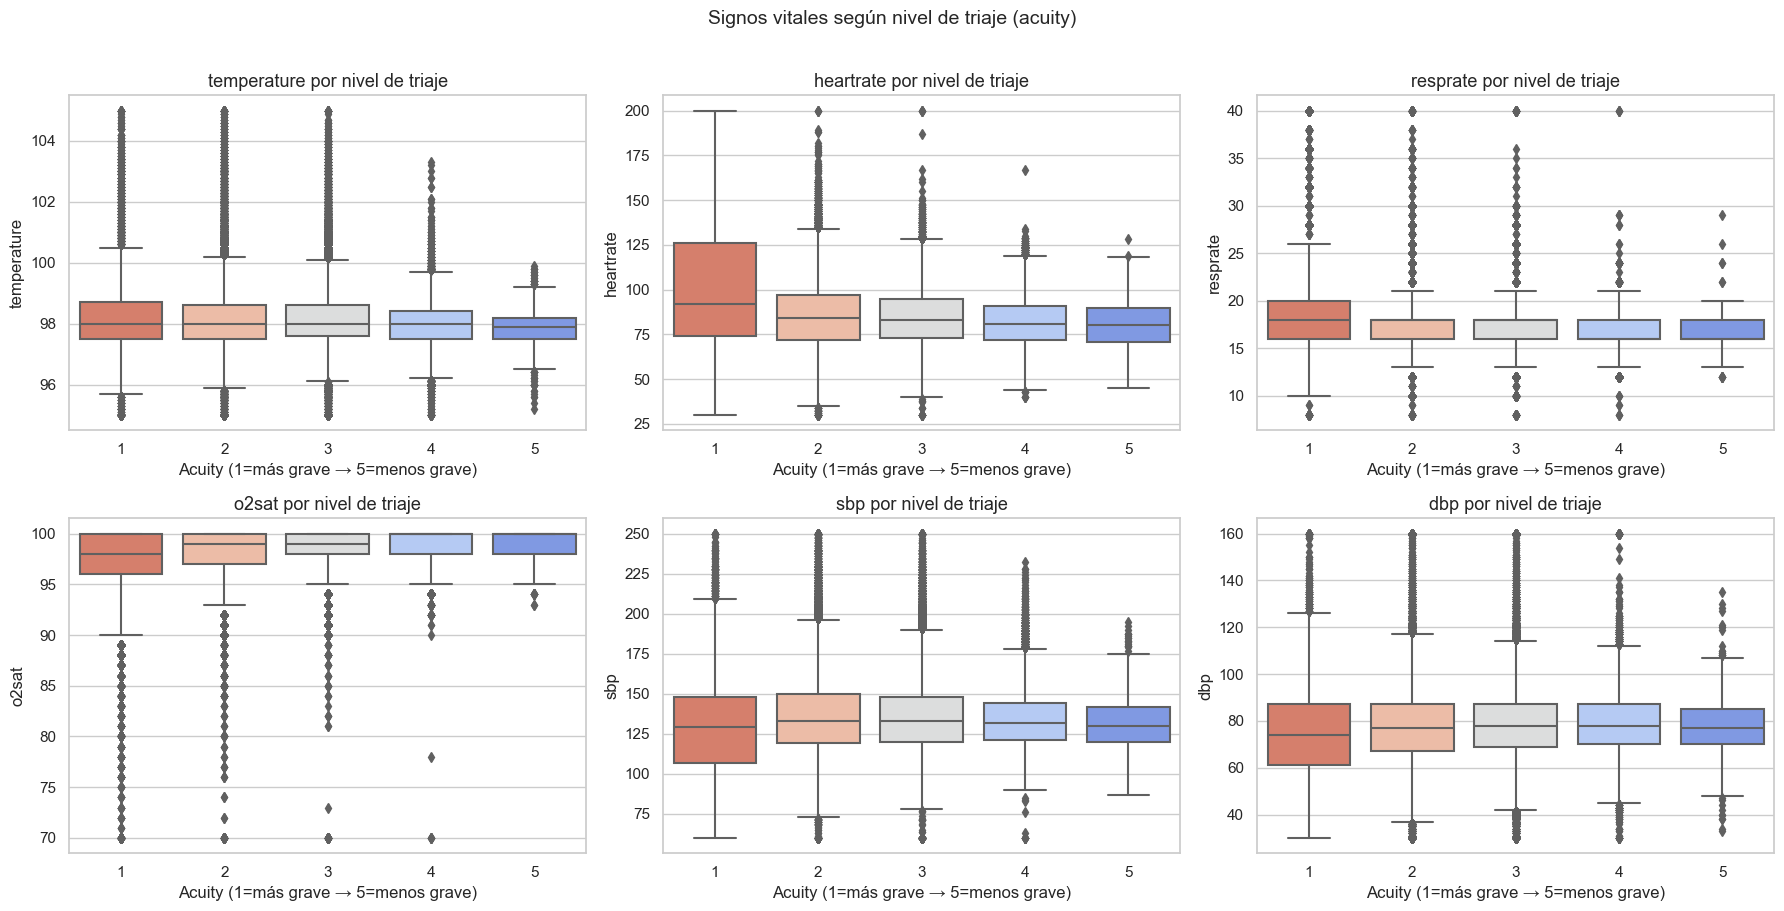

→ Se esperan diferencias claras: pacientes nivel 1 deben tener constantes más alteradas.


In [8]:
# ── 4.2 Boxplots: distribución por nivel de triaje (acuity 1–5) ──────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

vital_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']
clip_ranges = [(95,105), (30,200), (8,40), (70,100), (60,250), (30,160)]

for i, (col, (vmin, vmax)) in enumerate(zip(vital_cols, clip_ranges)):
    tmp = df_triage[['acuity', col]].dropna()
    tmp[col] = tmp[col].clip(vmin, vmax)
    tmp['acuity'] = tmp['acuity'].astype(int)
    sns.boxplot(data=tmp, x='acuity', y=col, palette='coolwarm_r', ax=axes[i])
    axes[i].set_title(f'{col} por nivel de triaje')
    axes[i].set_xlabel('Acuity (1=más grave → 5=menos grave)')

plt.suptitle('Signos vitales según nivel de triaje (acuity)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()
print('→ Se esperan diferencias claras: pacientes nivel 1 deben tener constantes más alteradas.')

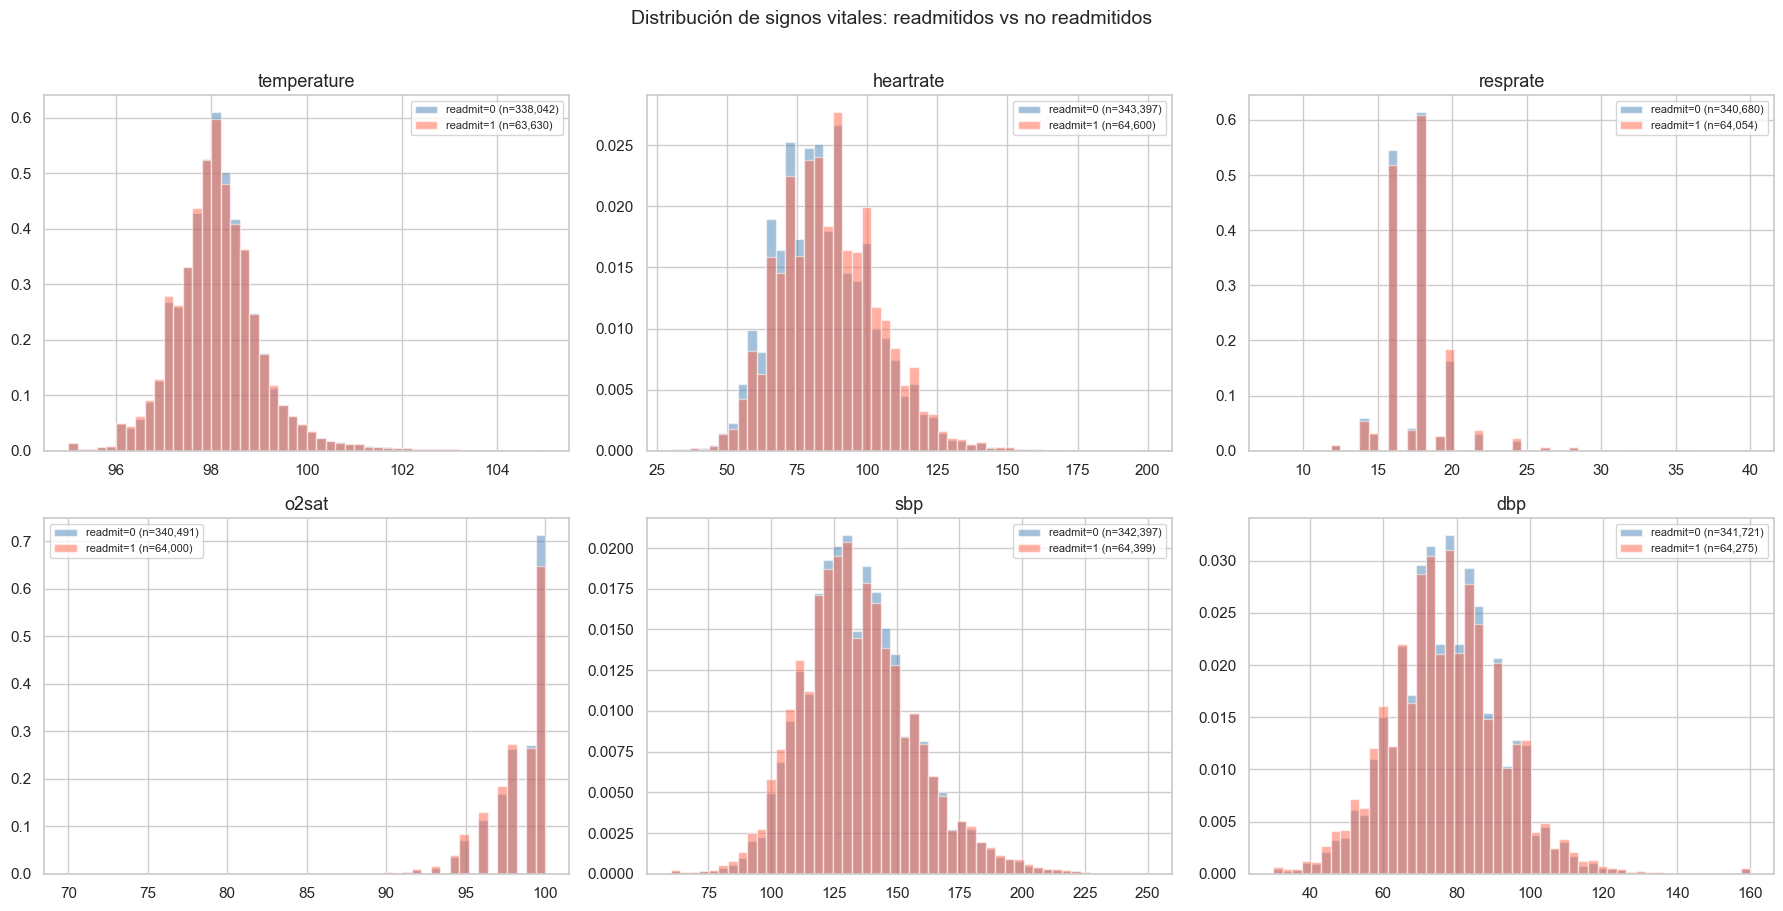

→ Las diferencias de distribución confirman que estas features tienen poder predictivo.


In [9]:
# ── 4.3 Distribución de constantes vitales: readmitidos vs no readmitidos ─────
triage_target = df_triage.merge(df_ed[['stay_id', 'readmit_30d']], on='stay_id', how='inner')

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, (col, (vmin, vmax)) in enumerate(zip(vital_cols, clip_ranges)):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        data = triage_target[triage_target['readmit_30d'] == label][col].dropna().clip(vmin, vmax)
        axes[i].hist(data, bins=50, alpha=0.5, color=color,
                     label=f'readmit={int(label)} (n={len(data):,})', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de signos vitales: readmitidos vs no readmitidos', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()
print('→ Las diferencias de distribución confirman que estas features tienen poder predictivo.')

---
## 5. Detección y tratamiento de Outliers

En datos médicos los outliers pueden ser:
- **Errores de entrada** (sbp=151103, temp=986°F) → eliminar/clippear
- **Valores clínicamente extremos pero reales** (FC=180 en taquicardia) → conservar pero escalar bien
- **Mezcla de unidades** (temperaturas en Celsius entre datos Fahrenheit) → corregir

In [10]:
# ── 5.1 Magnitud de outliers ANTES de limpiar ────────────────────────────────
print('Valores máximos RAW en triage (sin limpiar):')
raw_max = df_triage[vital_cols].max()
for col, val in raw_max.items():
    print(f'  {col:15s}: {val}')

print()
print('→ sbp máx 151,103 mmHg y dbp máx 661,672 mmHg son claramente errores de entrada.')
print('→ temperature máx 986°F es imposible biológicamente.')

Valores máximos RAW en triage (sin limpiar):
  temperature    : 986.0
  heartrate      : 1228.0
  resprate       : 1820.0
  o2sat          : 9322.0
  sbp            : 151103.0
  dbp            : 661672.0

→ sbp máx 151,103 mmHg y dbp máx 661,672 mmHg son claramente errores de entrada.
→ temperature máx 986°F es imposible biológicamente.


In [11]:
# ── 5.2 Problema especial: temperaturas en Celsius mezcladas con Fahrenheit ───
n_celsius_triage  = (df_triage['temperature'] < 45).sum()
n_fahrenheit_triage = (df_triage['temperature'] >= 45).sum()
n_celsius_vitals  = (df_vitals['temperature'] < 45).sum()

print(f'Triage — temperaturas < 45 (probablemente Celsius): {n_celsius_triage:,}')
print(f'Triage — temperaturas ≥ 45 (probablemente Fahrenheit): {n_fahrenheit_triage:,}')
print(f'Vitalsign — temperaturas < 45 (probablemente Celsius): {n_celsius_vitals:,}')
print()
print('Muestra de valores Celsius en triage:')
print(df_triage[df_triage['temperature'] < 45]['temperature'].value_counts().head(10))

Triage — temperaturas < 45 (probablemente Celsius): 475
Triage — temperaturas ≥ 45 (probablemente Fahrenheit): 401,197
Vitalsign — temperaturas < 45 (probablemente Celsius): 4,199

Muestra de valores Celsius en triage:
36.7    42
36.4    38
36.6    34
36.5    34
36.9    28
36.8    28
36.2    27
37.0    22
36.1    16
9.0     15
Name: temperature, dtype: int64


In [12]:
# ── 5.3 Función de limpieza clínica con rangos fisiológicos ──────────────────
# Rangos clínicamente plausibles para adultos en urgencias
CLINICAL_RANGES = {
    'temperature': (93.0, 108.0),   # °F: hipotermia severa a hipertermia letal
    'heartrate'  : (20, 300),        # bpm
    'resprate'   : (4, 60),          # rpm
    'o2sat'      : (50, 100),        # %
    'sbp'        : (40, 300),        # mmHg
    'dbp'        : (20, 200),        # mmHg
}

def fix_temperature(series):
    """Convierte temperaturas Celsius a Fahrenheit y descarta imposibles."""
    s = series.copy()
    # Si < 45, asumimos Celsius → convertir a F
    celsius_mask = s < 45
    s[celsius_mask] = s[celsius_mask] * 9/5 + 32
    # Descartar fuera de rango fisiológico
    s[(s < 93) | (s > 108)] = np.nan
    return s

def clip_to_clinical_range(df, ranges):
    """Aplica clip con rangos clínicos y reporta cuántos valores fueron corregidos."""
    df_clean = df.copy()
    for col, (lo, hi) in ranges.items():
        if col not in df_clean.columns:
            continue
        n_out_low  = (df_clean[col] < lo).sum()
        n_out_high = (df_clean[col] > hi).sum()
        total = df_clean[col].notna().sum()
        if n_out_low + n_out_high > 0:
            print(f'  {col:15s}: {n_out_low} bajo mínimo ({lo}), {n_out_high} sobre máximo ({hi})'
                  f'  →  {100*(n_out_low+n_out_high)/total:.2f}% del total')
        df_clean[col] = df_clean[col].clip(lo, hi)
    return df_clean

print('=== Limpieza de Triage ===')
df_triage_clean = df_triage.copy()
df_triage_clean['temperature'] = fix_temperature(df_triage_clean['temperature'])
df_triage_clean = clip_to_clinical_range(df_triage_clean, CLINICAL_RANGES)

print()
print('=== Limpieza de Vitalsign ===')
df_vitals_clean = df_vitals.copy()
df_vitals_clean['temperature'] = fix_temperature(df_vitals_clean['temperature'])
df_vitals_clean = clip_to_clinical_range(df_vitals_clean, CLINICAL_RANGES)

=== Limpieza de Triage ===
  heartrate      : 22 bajo mínimo (20), 7 sobre máximo (300)  →  0.01% del total
  resprate       : 19 bajo mínimo (4), 39 sobre máximo (60)  →  0.01% del total
  o2sat          : 92 bajo mínimo (50), 47 sobre máximo (100)  →  0.03% del total
  sbp            : 186 bajo mínimo (40), 17 sobre máximo (300)  →  0.05% del total
  dbp            : 152 bajo mínimo (20), 441 sobre máximo (200)  →  0.15% del total

=== Limpieza de Vitalsign ===
  heartrate      : 629 bajo mínimo (20), 10 sobre máximo (300)  →  0.04% del total
  resprate       : 221 bajo mínimo (4), 315 sobre máximo (60)  →  0.04% del total
  o2sat          : 814 bajo mínimo (50), 38 sobre máximo (100)  →  0.06% del total
  sbp            : 2328 bajo mínimo (40), 4 sobre máximo (300)  →  0.16% del total
  dbp            : 438 bajo mínimo (20), 1021 sobre máximo (200)  →  0.10% del total


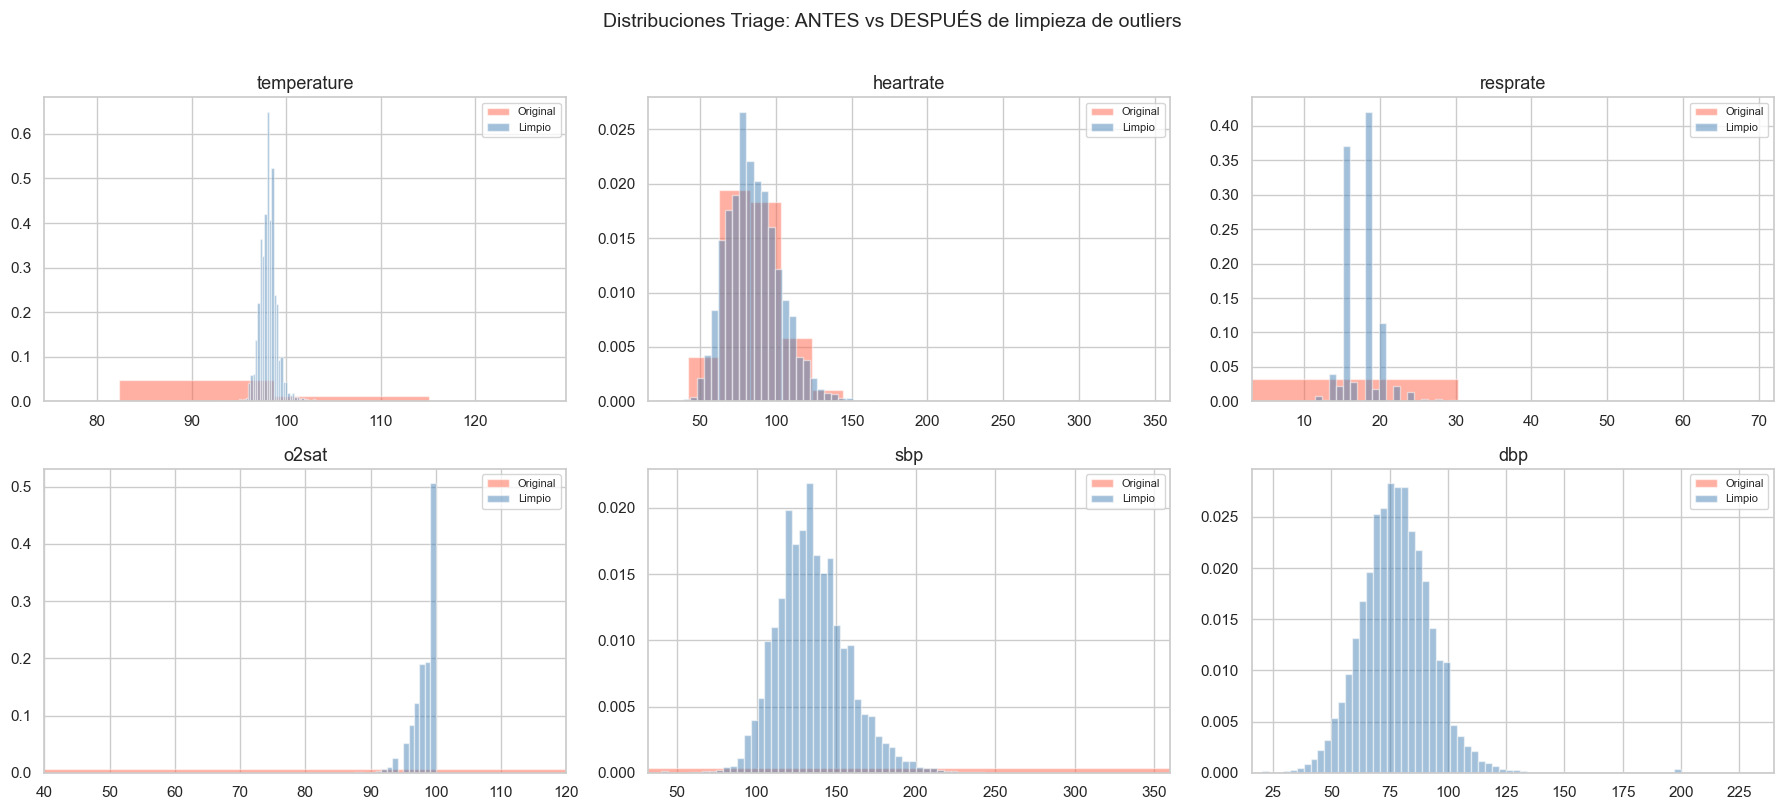

In [13]:
# ── 5.4 Comparación visual ANTES vs DESPUÉS de limpieza ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

compare_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']
for i, col in enumerate(compare_cols):
    ax = axes[i // 3][i % 3]
    lo, hi = CLINICAL_RANGES[col]
    ax.hist(df_triage[col].dropna(), bins=60, alpha=0.5, color='tomato', label='Original', density=True)
    ax.hist(df_triage_clean[col].dropna(), bins=60, alpha=0.5, color='steelblue', label='Limpio', density=True)
    ax.set_title(col)
    ax.set_xlim(lo * 0.8, hi * 1.2)
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones Triage: ANTES vs DESPUÉS de limpieza de outliers', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# ── 5.5 Z-score para detectar outliers residuales ────────────────────────────
print('Z-score medio por columna (triage limpio):')
print('(valores > 3 σ son outliers estadísticos residuales)\n')

for col in compare_cols:
    s = df_triage_clean[col].dropna()
    z = np.abs(stats.zscore(s))
    n_3sig = (z > 3).sum()
    n_5sig = (z > 5).sum()
    print(f'  {col:15s}: {n_3sig:5,} (>{"3σ"})  |  {n_5sig:5,} (>{"5σ"})')

print()
print('→ Para DL usaremos RobustScaler (resistente a outliers) en lugar de StandardScaler.')
print('→ Los outliers residuales a 3σ dentro del rango clínico los conservaremos: son reales.')

Z-score medio por columna (triage limpio):
(valores > 3 σ son outliers estadísticos residuales)

  temperature    : 6,163 (>3σ)  |  1,065 (>5σ)
  heartrate      : 2,929 (>3σ)  |    157 (>5σ)
  resprate       : 5,248 (>3σ)  |  1,790 (>5σ)
  o2sat          : 3,111 (>3σ)  |  1,059 (>5σ)
  sbp            : 3,221 (>3σ)  |     93 (>5σ)
  dbp            : 2,363 (>3σ)  |    574 (>5σ)

→ Para DL usaremos RobustScaler (resistente a outliers) en lugar de StandardScaler.
→ Los outliers residuales a 3σ dentro del rango clínico los conservaremos: son reales.


---
## 6. Feature Engineering avanzado

Creamos features que no están directamente en los datos pero que son clínicamente relevantes para predecir readmisiones.

In [15]:
# ── 6.1 Features de signos vitales en triage (ya disponibles al ingreso) ──────
df_triage_feat = df_triage_clean.copy()

# Presión de pulso (PP = sbp - dbp): marcador de rigidez arterial
df_triage_feat['pulse_pressure'] = df_triage_feat['sbp'] - df_triage_feat['dbp']

# Shock Index = HR / SBP: >1.0 sugiere shock hemodinámico
df_triage_feat['shock_index'] = df_triage_feat['heartrate'] / df_triage_feat['sbp'].replace(0, np.nan)

# MAP = (sbp + 2*dbp) / 3: presión arterial media
df_triage_feat['map'] = (df_triage_feat['sbp'] + 2 * df_triage_feat['dbp']) / 3

# Pain numérico: convertir texto libre a escala 0-10
def parse_pain(val):
    try:
        v = float(str(val).strip())
        return v if 0 <= v <= 10 else np.nan
    except:
        return np.nan

df_triage_feat['pain_numeric'] = df_triage_feat['pain'].apply(parse_pain)

# Indicadores binarios de missingness (informativo en datos médicos)
for col in ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']:
    df_triage_feat[f'{col}_missing'] = df_triage_feat[col].isnull().astype(int)

new_feats = ['pulse_pressure', 'shock_index', 'map', 'pain_numeric']
print('Nuevas features de triage:')
print(df_triage_feat[new_feats].describe().round(2))

Nuevas features de triage:
       pulse_pressure  shock_index        map  pain_numeric
count       405994.00    405996.00  405994.00     385769.00
mean            57.37         0.65      96.71          4.17
std             20.28         0.18      15.21          3.75
min           -160.00         0.12      26.67          0.00
25%             44.00         0.53      86.67          0.00
50%             55.00         0.63      96.00          4.00
75%             68.00         0.74     106.00          8.00
max            280.00         4.15     215.00         10.00


In [16]:
# ── 6.2 Agregados de signos vitales durante la visita (vitalsign) ─────────────
# Agrupamos por stay_id: media, std, min, max y nº de mediciones

vs_agg_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

agg_funcs = {col: ['mean', 'std', 'min', 'max'] for col in vs_agg_cols}
agg_funcs['charttime'] = 'count'  # número de mediciones

vs_agg = df_vitals_clean.groupby('stay_id').agg(agg_funcs)
vs_agg.columns = ['_'.join(c).strip() for c in vs_agg.columns]
vs_agg = vs_agg.rename(columns={'charttime_count': 'n_vitals_measurements'})
vs_agg = vs_agg.reset_index()

# Features adicionales de variabilidad fisiológica
# (alta variabilidad de HR o BP durante la estancia es clínicamente relevante)
vs_agg['hr_range']  = vs_agg['heartrate_max'] - vs_agg['heartrate_min']
vs_agg['sbp_range'] = vs_agg['sbp_max'] - vs_agg['sbp_min']
vs_agg['o2_min_alert'] = (vs_agg['o2sat_min'] < 94).astype(int)  # hipoxia

print(f'Agregados de vitalsign: {vs_agg.shape[1]} columnas para {vs_agg.shape[0]:,} visitas')
print(vs_agg[['heartrate_mean', 'heartrate_std', 'hr_range', 'sbp_range', 'o2_min_alert']].describe().round(2))

Agregados de vitalsign: 29 columnas para 408,146 visitas
       heartrate_mean  heartrate_std   hr_range  sbp_range  o2_min_alert
count       406649.00      326990.00  406649.00  406410.00     408146.00
mean            79.87           7.46      12.81      18.87          0.07
std             14.52           5.80      13.72      19.16          0.25
min             20.00           0.00       0.00       0.00          0.00
25%             69.70           3.52       2.00       3.00          0.00
50%             78.57           6.17      10.00      15.00          0.00
75%             88.67           9.90      19.00      29.00          0.00
max            197.91         153.44     242.00     231.00          1.00


In [17]:
# ── 6.3 Features de diagnóstico ───────────────────────────────────────────────
# Número de diagnósticos por visita
diag_count = df_diag.groupby('stay_id').agg(
    num_diagnoses=('icd_code', 'count'),
    num_icd10=('icd_version', lambda x: (x == 10).sum()),
    num_icd9=('icd_version', lambda x: (x == 9).sum()),
).reset_index()

# Top 20 diagnósticos más comunes como features binarias (one-hot sparse)
top_diag = df_diag['icd_title'].value_counts().head(20).index.tolist()
diag_wide = df_diag[df_diag['icd_title'].isin(top_diag)].copy()
diag_wide['icd_clean'] = diag_wide['icd_title'].str.lower().str.replace(' ', '_').str[:30]
diag_dummies = pd.get_dummies(diag_wide[['stay_id', 'icd_clean']], columns=['icd_clean'])
diag_dummies = diag_dummies.groupby('stay_id').max().reset_index()

diag_feat = diag_count.merge(diag_dummies, on='stay_id', how='left')
print(f'Features de diagnóstico: {diag_feat.shape[1]} columnas para {diag_feat.shape[0]:,} visitas')

Features de diagnóstico: 23 columnas para 423,989 visitas


In [18]:
# ── 6.4 Features de medicación (pyxis) ───────────────────────────────────────
pyxis_count = df_pyxis.groupby('stay_id').agg(
    num_meds_dispensed=('name', 'count'),
    num_unique_meds=('name', 'nunique'),
).reset_index()

# Top 15 medicamentos como features binarias
top_meds = df_pyxis['name'].value_counts().head(15).index.tolist()
pyxis_top = df_pyxis[df_pyxis['name'].isin(top_meds)].copy()
pyxis_top['med_clean'] = 'med_' + pyxis_top['name'].str.lower().str.replace(' ', '_').str[:20]
pyxis_dummies = pd.get_dummies(pyxis_top[['stay_id', 'med_clean']], columns=['med_clean'])
pyxis_dummies = pyxis_dummies.groupby('stay_id').max().reset_index()

pyxis_feat = pyxis_count.merge(pyxis_dummies, on='stay_id', how='left')
print(f'Features de medicación: {pyxis_feat.shape[1]} columnas para {pyxis_feat.shape[0]:,} visitas')

Features de medicación: 18 columnas para 303,361 visitas


In [19]:
# ── 6.5 Features temporales y de historial del paciente ───────────────────────
df_hist = df_ed.sort_values(['subject_id', 'intime']).copy()

# Duración de la estancia en urgencias (horas)
df_hist['ed_stay_hours'] = (df_hist['outtime'] - df_hist['intime']).dt.total_seconds() / 3600
df_hist['ed_stay_hours'] = df_hist['ed_stay_hours'].clip(0, 72)  # max 72h

# Número de visitas previas del mismo paciente (historial)
df_hist['visit_number'] = df_hist.groupby('subject_id').cumcount() + 1
df_hist['is_return_visit'] = (df_hist['visit_number'] > 1).astype(int)

# Días desde la visita anterior
df_hist['prev_outtime'] = df_hist.groupby('subject_id')['outtime'].shift(1)
df_hist['days_since_prev_visit'] = (
    (df_hist['intime'] - df_hist['prev_outtime']).dt.total_seconds() / 86400
).clip(0, 365)

# Features temporales (hora del día, día de la semana)
df_hist['arrival_hour'] = df_hist['intime'].dt.hour
df_hist['arrival_dow']  = df_hist['intime'].dt.dayofweek  # 0=lunes
df_hist['arrival_weekend'] = (df_hist['arrival_dow'] >= 5).astype(int)

# Ingresado en hospital (hadm_id presente)
df_hist['was_admitted'] = df_hist['hadm_id'].notna().astype(int)

temporal_feats = ['ed_stay_hours', 'visit_number', 'is_return_visit',
                  'days_since_prev_visit', 'arrival_hour', 'arrival_weekend', 'was_admitted']
print('Features temporales y de historial:')
print(df_hist[temporal_feats].describe().round(2))

Features temporales y de historial:
       ed_stay_hours  visit_number  is_return_visit  days_since_prev_visit  \
count      425087.00     425087.00        425087.00              219583.00   
mean            7.14          4.38             0.52                 154.65   
std             6.39         10.55             0.50                 144.22   
min             0.00          1.00             0.00                   0.00   
25%             3.53          1.00             0.00                  21.05   
50%             5.47          2.00             1.00                  95.82   
75%             8.32          4.00             1.00                 341.49   
max            72.00        321.00             1.00                 365.00   

       arrival_hour  arrival_weekend  was_admitted  
count     425087.00        425087.00     425087.00  
mean          13.48             0.29          0.48  
std            5.89             0.45          0.50  
min            0.00             0.00          0.0

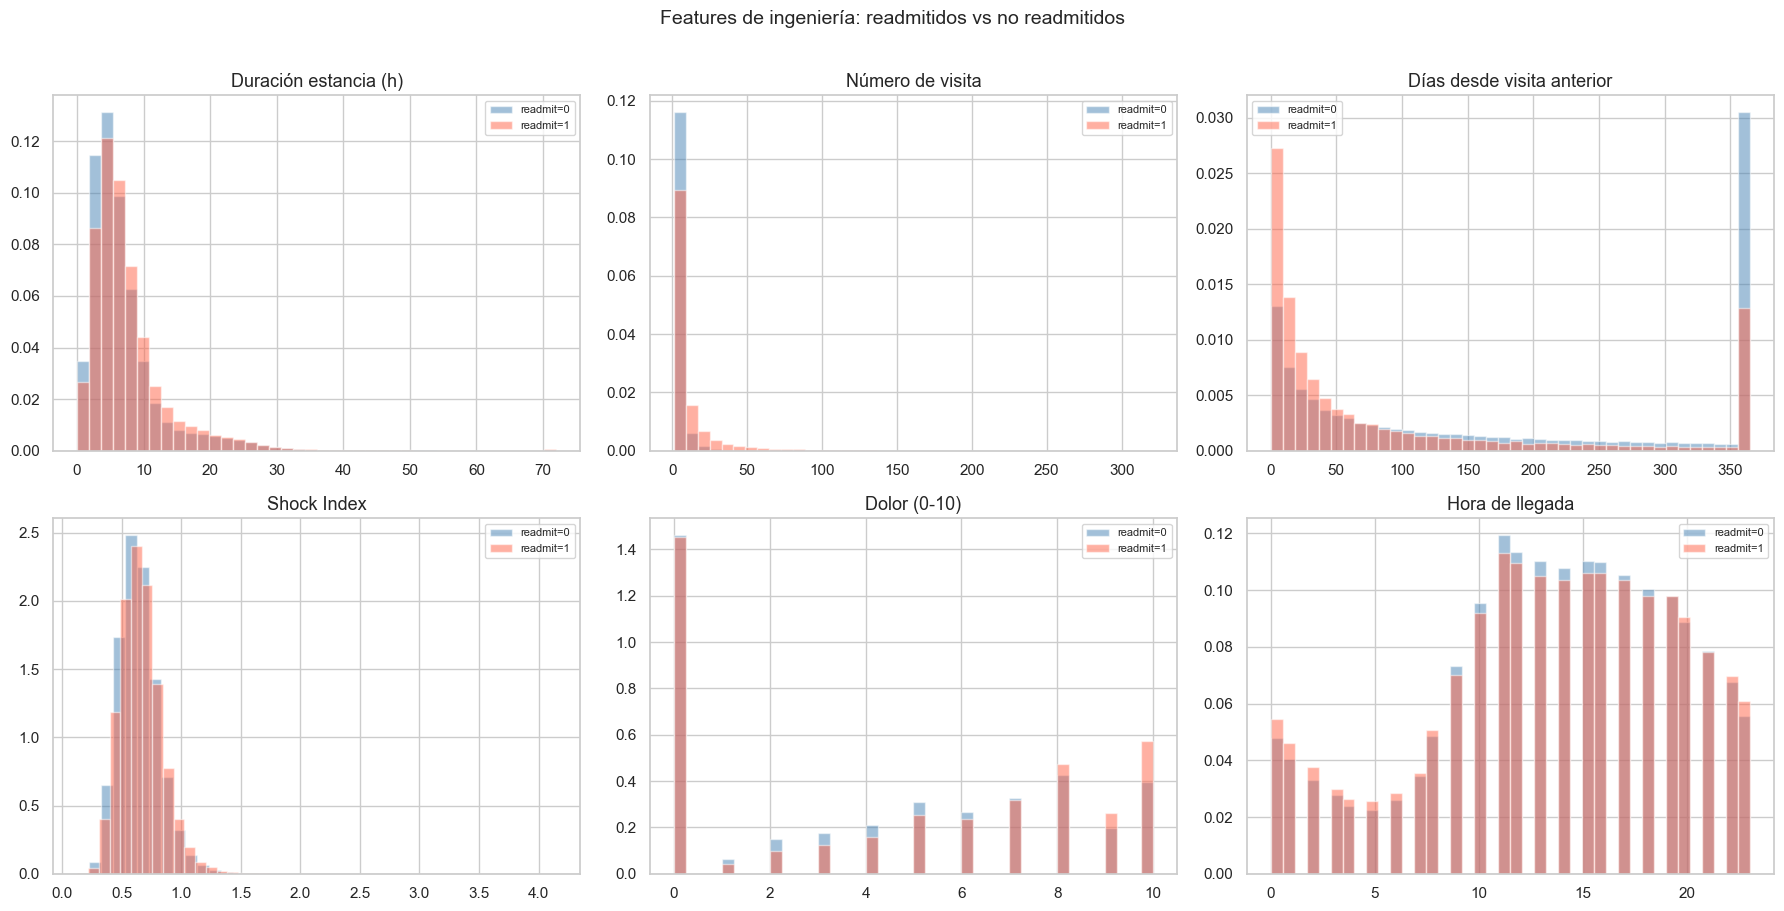

In [20]:
# ── 6.6 Visualización de importancia de nuevas features ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

merged_vis = df_hist.merge(df_triage_feat[['stay_id', 'acuity', 'shock_index', 'pain_numeric']], 
                            on='stay_id', how='left')

plot_feats = [
    ('ed_stay_hours', 'Duración estancia (h)'),
    ('visit_number', 'Número de visita'),
    ('days_since_prev_visit', 'Días desde visita anterior'),
    ('shock_index', 'Shock Index'),
    ('pain_numeric', 'Dolor (0-10)'),
    ('arrival_hour', 'Hora de llegada'),
]

for i, (feat, title) in enumerate(plot_feats):
    if feat not in merged_vis.columns:
        axes[i].axis('off')
        continue
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        data = merged_vis[merged_vis['readmit_30d'] == label][feat].dropna()
        axes[i].hist(data, bins=40, alpha=0.5, density=True, color=color,
                     label=f'readmit={int(label)}')
    axes[i].set_title(title)
    axes[i].legend(fontsize=8)

plt.suptitle('Features de ingeniería: readmitidos vs no readmitidos', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. Encoding de variables categóricas

Para Deep Learning evitamos el one-hot clásico en variables de alta cardinalidad (como `race` con 33 valores) y en su lugar usamos **embeddings aprendibles** o **label encoding** (el modelo aprende la representación).

¿Qué hice con las categóricas?
Dos cosas, y aquí está el problema:

Label Encoding: asigna un número entero a cada categoría (WHITE=28, BLACK=3...). Esto está bien solo si luego lo pasas por una capa Embedding en PyTorch/TensorFlow — la red aprende la representación. Si lo metes directamente como número en el input, le estás diciendo implícitamente que WHITE > BLACK > OTHER numéricamente, lo cual no tiene sentido.
Frequency encoding: reemplaza cada categoría por su frecuencia relativa en el dataset. Esto sí se puede meter directo como feature numérica, pero pierde información y puede causar data leakage si no lo calculas solo sobre train.

Lo que realmente deberías hacer depende del modelo DL que elijas:

MLP: One-hot para baja cardinalidad (gender, arrival_transport) + frequency/target encoding para race y disposition
TabNet / FT-Transformer: estos modelos tienen soporte nativo para categóricas con embedding, y el label encoding es exactamente lo que necesitan como input

In [34]:
from sklearn.preprocessing import LabelEncoder

# ── 7.1 Variables categóricas identificadas ───────────────────────────────────
cat_vars = {
    'gender'            : df_ed['gender'].nunique(),
    'race'              : df_ed['race'].nunique(),
    'arrival_transport' : df_ed['arrival_transport'].nunique(),
    'disposition'       : df_ed['disposition'].nunique(),
}

print('Variables categóricas:')
print(f'{"Variable":25s} {"Cardinalidad":>15s} {"Estrategia recomendada":>30s}')
print('-'*75)
for var, card in cat_vars.items():
    strategy = 'One-Hot' if card <= 5 else 'Embedding DL' if card <= 50 else 'Hashing / Embedding'
    print(f'{var:25s} {card:>15d} {strategy:>30s}')

print()
print('Regla general para DL:')
print('  - Cardinalidad ≤ 5  → One-Hot (pocas dimensiones extra)')
print('  - Cardinalidad 6-50 → Embedding aprendible (dim = min(50, card//2))')
print('  - Cardinalidad > 50 → Embedding o Feature Hashing')

Variables categóricas:
Variable                     Cardinalidad         Estrategia recomendada
---------------------------------------------------------------------------
gender                                  2                        One-Hot
race                                   33                   Embedding DL
arrival_transport                       5                        One-Hot
disposition                             8                   Embedding DL

Regla general para DL:
  - Cardinalidad ≤ 5  → One-Hot (pocas dimensiones extra)
  - Cardinalidad 6-50 → Embedding aprendible (dim = min(50, card//2))
  - Cardinalidad > 50 → Embedding o Feature Hashing


In [22]:
# ── 7.2 Label Encoding (para embeddings en PyTorch/TensorFlow) ───────────────
df_cat = df_hist[['stay_id', 'gender', 'race', 'arrival_transport', 'disposition']].copy()

# Rellenar nulos antes de encodear
for col in ['gender', 'race', 'arrival_transport', 'disposition']:
    df_cat[col] = df_cat[col].fillna('UNKNOWN')

label_encoders = {}
for col in ['gender', 'race', 'arrival_transport', 'disposition']:
    le = LabelEncoder()
    df_cat[f'{col}_enc'] = le.fit_transform(df_cat[col])
    label_encoders[col] = le
    n_classes = len(le.classes_)
    emb_dim = min(50, max(4, n_classes // 2))
    print(f'{col}: {n_classes} clases → Embedding dim sugerida: {emb_dim}')

print()
print('Muestra del encoding:')
enc_cols = [c for c in df_cat.columns if c.endswith('_enc')]
print(df_cat[['stay_id'] + enc_cols].head())

gender: 2 clases → Embedding dim sugerida: 4
race: 33 clases → Embedding dim sugerida: 16
arrival_transport: 5 clases → Embedding dim sugerida: 4
disposition: 8 clases → Embedding dim sugerida: 4

Muestra del encoding:
    stay_id  gender_enc  race_enc  arrival_transport_enc  disposition_enc
0  33258284           0        28                      0                0
1  38112554           0        28                      0                0
3  32952584           0        28                      0                3
4  39399961           0        28                      0                0
2  35968195           0        28                      0                0


In [23]:
# ── 7.3 Frecuencia de cada categoría (target encoding alternativo) ────────────
# Útil como feature numérica alternativa a embeddings
for col in ['race', 'arrival_transport', 'disposition']:
    freq = df_cat[col].value_counts(normalize=True)
    df_cat[f'{col}_freq'] = df_cat[col].map(freq)

print('Frequency encoding de race (top 5):')
print(df_cat.groupby('race')['race_freq'].first().sort_values(ascending=False).head(5))

Frequency encoding de race (top 5):
race
WHITE                             0.536650
BLACK/AFRICAN AMERICAN            0.180664
OTHER                             0.048818
HISPANIC/LATINO - PUERTO RICAN    0.033019
WHITE - OTHER EUROPEAN            0.021153
Name: race_freq, dtype: float64


---
## 8. Normalización y Escalado

Para Deep Learning, el escalado es **crítico**: gradientes inestables si las features tienen escalas muy distintas. Comparamos 3 estrategias:
- **StandardScaler**: media=0, std=1. Sensible a outliers.
- **MinMaxScaler**: rango [0,1]. Muy sensible a outliers.
- **RobustScaler**: usa mediana y IQR. **Recomendado para datos médicos con outliers.**

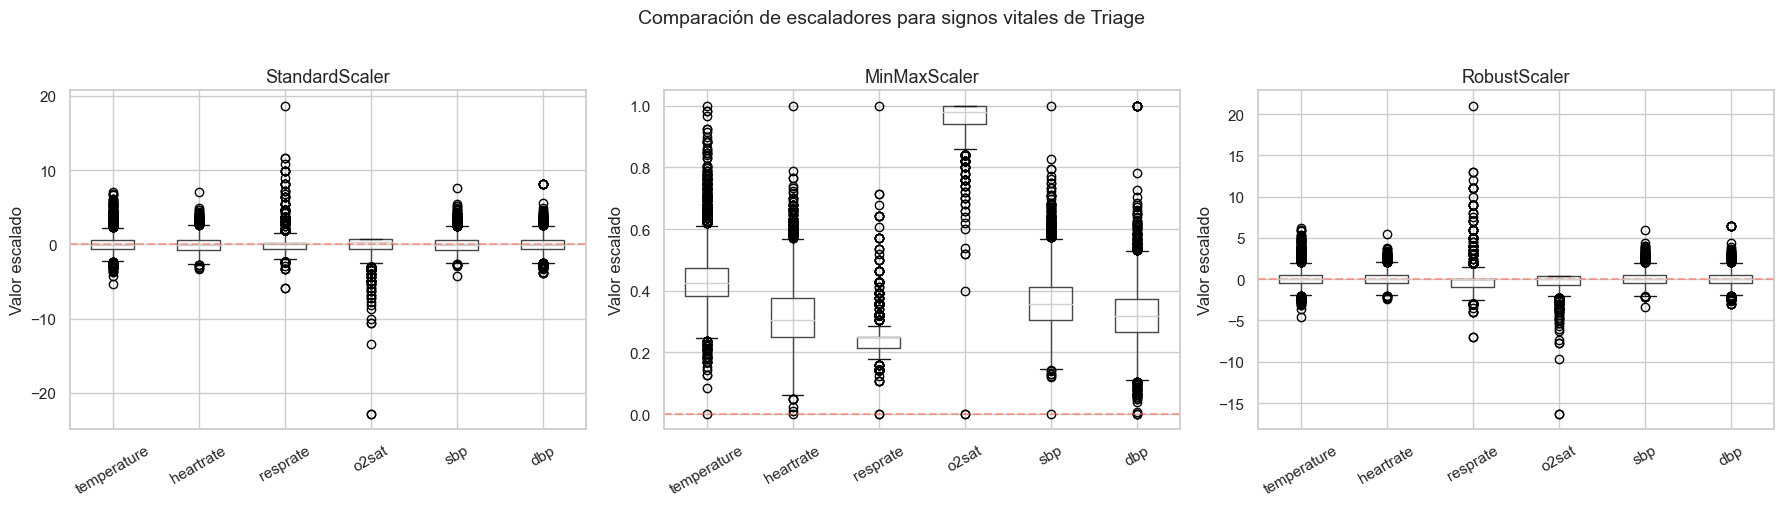

→ RobustScaler produce distribuciones más simétricas con outliers médicos.
→ MinMaxScaler se distorsiona: sbp y dbp tienen outliers extremos que comprimen todo.


In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# ── 8.1 Comparación de scalers en datos de triage ────────────────────────────
cols_to_scale = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']
sample = df_triage_clean[cols_to_scale].dropna().sample(10000, random_state=42)

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler'  : MinMaxScaler(),
    'RobustScaler'  : RobustScaler(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, scaler) in zip(axes, scalers.items()):
    scaled = scaler.fit_transform(sample)
    scaled_df = pd.DataFrame(scaled, columns=cols_to_scale)
    scaled_df.boxplot(ax=ax, rot=30)
    ax.set_title(name)
    ax.set_ylabel('Valor escalado')
    ax.axhline(0, color='tomato', linestyle='--', alpha=0.5)

plt.suptitle('Comparación de escaladores para signos vitales de Triage', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

print('→ RobustScaler produce distribuciones más simétricas con outliers médicos.')
print('→ MinMaxScaler se distorsiona: sbp y dbp tienen outliers extremos que comprimen todo.')

In [27]:
# ── 8.2 Estadísticas de cada scaler ──────────────────────────────────────────
print(f"{'Columna':15s}  {'Original std':>14s}  {'StandardScaler std':>20s}  {'RobustScaler std':>18s}")
print('-' * 75)

std_scaler = StandardScaler().fit(sample)
rob_scaler = RobustScaler().fit(sample)

std_scaled = std_scaler.transform(sample)
rob_scaled = rob_scaler.transform(sample)

for i, col in enumerate(cols_to_scale):
    orig_std = sample[col].std()
    std_s    = std_scaled[:, i].std()
    rob_s    = rob_scaled[:, i].std()
    print(f'{col:15s}  {orig_std:>14.2f}  {std_s:>20.3f}  {rob_s:>18.3f}')

Columna            Original std    StandardScaler std    RobustScaler std
---------------------------------------------------------------------------
temperature                0.95                 1.000               0.866
heartrate                 17.47                 1.000               0.760
resprate                   2.28                 1.000               1.139
o2sat                      2.12                 1.000               0.706
sbp                       21.99                 1.000               0.785
dbp                       14.96                 1.000               0.787


---
## 9. Dataset final: ensamblado y guardado

Unimos todas las features procesadas en un único dataframe listo para entrenar el modelo DL.

In [28]:
# ── 9.1 Unir todas las tablas de features ─────────────────────────────────────
# Base: una fila por visita (stay_id)
df_final = df_hist[['stay_id', 'subject_id', 'readmit_30d',
                     'ed_stay_hours', 'visit_number', 'is_return_visit',
                     'days_since_prev_visit', 'arrival_hour', 'arrival_dow',
                     'arrival_weekend', 'was_admitted']].copy()

# Triage features
triage_cols = ['stay_id', 'temperature', 'heartrate', 'resprate', 'o2sat',
               'sbp', 'dbp', 'acuity', 'pulse_pressure', 'shock_index',
               'map', 'pain_numeric'] + \
              [c for c in df_triage_feat.columns if c.endswith('_missing')]
df_final = df_final.merge(df_triage_feat[triage_cols], on='stay_id', how='left')

# Vitalsign agregados
df_final = df_final.merge(vs_agg, on='stay_id', how='left')

# Diagnóstico
df_final = df_final.merge(diag_feat, on='stay_id', how='left')

# Medicación
df_final = df_final.merge(pyxis_feat, on='stay_id', how='left')

# Categóricas encoded
enc_cols = ['stay_id'] + [c for c in df_cat.columns if '_enc' in c or '_freq' in c]
df_final = df_final.merge(df_cat[enc_cols], on='stay_id', how='left')

print(f'Dataset final: {df_final.shape[0]:,} visitas × {df_final.shape[1]} columnas')
print(f'Target: {df_final["readmit_30d"].value_counts().to_dict()}')

Dataset final: 425,087 visitas × 102 columnas
Target: {0.0: 358531, 1.0: 66556}


In [29]:
# ── 9.2 Imputación de NaNs residuales (mediana para numéricos, -1 para binarios) ──
# Separar columnas por tipo
id_cols     = ['stay_id', 'subject_id', 'readmit_30d']
binary_cols = [c for c in df_final.columns if c.endswith('_missing') or c.startswith('med_') or
               c.startswith('icd_clean_') or c in ['is_return_visit', 'arrival_weekend', 'was_admitted', 'o2_min_alert']]
num_cols    = [c for c in df_final.columns if c not in id_cols + binary_cols]

print(f'Columnas numéricas continuas : {len(num_cols)}')
print(f'Columnas binarias/indicadoras: {len(binary_cols)}')

# Imputar numéricos con mediana
for col in num_cols:
    if df_final[col].isnull().any():
        df_final[col] = df_final[col].fillna(df_final[col].median())

# Imputar binarios con 0 (ausencia de medicación/diagnóstico → 0 es correcto)
for col in binary_cols:
    if df_final[col].isnull().any():
        df_final[col] = df_final[col].fillna(0)

total_nan = df_final.drop(columns=id_cols).isnull().sum().sum()
print(f'\nNaNs residuales tras imputación: {total_nan}')

Columnas numéricas continuas : 55
Columnas binarias/indicadoras: 44

NaNs residuales tras imputación: 0


In [30]:
# ── 9.3 Aplicar RobustScaler sobre features numéricas continuas ───────────────
from sklearn.preprocessing import RobustScaler

# Excluir columnas ya en escala natural pequeña o binarias
skip_scaling = binary_cols + ['acuity', 'visit_number', 'arrival_hour', 'arrival_dow',
                               'gender_enc', 'race_enc', 'arrival_transport_enc', 'disposition_enc',
                               'num_diagnoses', 'num_icd10', 'num_icd9',
                               'num_meds_dispensed', 'num_unique_meds', 'n_vitals_measurements']

cols_to_scale_final = [c for c in num_cols if c not in skip_scaling]

scaler_final = RobustScaler()
df_final[cols_to_scale_final] = scaler_final.fit_transform(df_final[cols_to_scale_final])

print(f'Features escaladas con RobustScaler: {len(cols_to_scale_final)}')
print('Estadísticas post-escalado (deben estar centradas en ~0):')
print(df_final[cols_to_scale_final[:6]].describe().round(3))

Features escaladas con RobustScaler: 41
Estadísticas post-escalado (deben estar centradas en ~0):
       ed_stay_hours  days_since_prev_visit  temperature   heartrate  \
count     425087.000             425087.000   425087.000  425087.000   
mean           0.351                  1.815        0.092       0.047   
std            1.335                  6.435        1.031       0.788   
min           -1.143                 -5.723       -5.556      -2.909   
25%           -0.404                 -0.476       -0.444      -0.500   
50%            0.000                  0.000        0.000       0.000   
75%            0.596                  0.524        0.556       0.500   
max           13.909                 16.076       10.778       9.818   

         resprate       o2sat  
count  425087.000  425087.000  
mean       -0.215      -0.293  
std         1.152       1.068  
min        -7.000     -24.500  
25%        -1.000      -0.500  
50%         0.000       0.000  
75%         0.000       0.500

In [31]:
# ── 9.4 Resumen del desbalance de clases y estrategias para DL ───────────────
n_pos = int(df_final['readmit_30d'].sum())
n_neg = len(df_final) - n_pos
ratio = n_neg / n_pos

print('='*60)
print('DESBALANCE DE CLASES')
print('='*60)
print(f'Positivos (readmit=1): {n_pos:,}  ({100*n_pos/len(df_final):.1f}%)')
print(f'Negativos (readmit=0): {n_neg:,}  ({100*n_neg/len(df_final):.1f}%)')
print(f'Ratio negativo:positivo = {ratio:.1f}:1')
print()
print('Estrategias recomendadas para DL:')
print(f'  1. class_weight = {{0: 1.0, 1: {ratio:.1f}}} en la función de pérdida')
print(f'  2. Focal Loss (penaliza más los ejemplos difíciles — estándar en medical DL)')
print(f'  3. Oversample minoritaria con RandomOverSampler o SMOTE')
print(f'  4. Métrica principal: AUC-ROC y F1, NO accuracy (engañosa con desbalance)')

DESBALANCE DE CLASES
Positivos (readmit=1): 66,556  (15.7%)
Negativos (readmit=0): 358,531  (84.3%)
Ratio negativo:positivo = 5.4:1

Estrategias recomendadas para DL:
  1. class_weight = {0: 1.0, 1: 5.4} en la función de pérdida
  2. Focal Loss (penaliza más los ejemplos difíciles — estándar en medical DL)
  3. Oversample minoritaria con RandomOverSampler o SMOTE
  4. Métrica principal: AUC-ROC y F1, NO accuracy (engañosa con desbalance)


In [32]:
# ── 9.5 Guardar dataset final ─────────────────────────────────────────────────
output_path = 'df_preprocessed_dl.parquet'
df_final.to_parquet(output_path, index=False)

print('='*60)
print('DATASET FINAL GUARDADO')
print('='*60)
print(f'Archivo: {output_path}')
print(f'Shape  : {df_final.shape}')
print(f'Tamaño : {df_final.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Columnas incluidas:')
print(f'  - {len(num_cols)} features numéricas continuas (escaladas con RobustScaler)')
print(f'  - {len(binary_cols)} features binarias / indicadoras')
print(f'  - 4 columnas categóricas encoded (para embeddings DL)')
print(f'  - 1 columna target: readmit_30d')
print()
print('Próximos pasos:')
print('  → 04_Model_DL.ipynb: MLP, TabNet, o FT-Transformer sobre este dataset')

DATASET FINAL GUARDADO
Archivo: df_preprocessed_dl.parquet
Shape  : (425087, 102)
Tamaño : 350.3 MB

Columnas incluidas:
  - 55 features numéricas continuas (escaladas con RobustScaler)
  - 44 features binarias / indicadoras
  - 4 columnas categóricas encoded (para embeddings DL)
  - 1 columna target: readmit_30d

Próximos pasos:
  → 04_Model_DL.ipynb: MLP, TabNet, o FT-Transformer sobre este dataset
